In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

plt.rcParams["font.size"] = 15

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


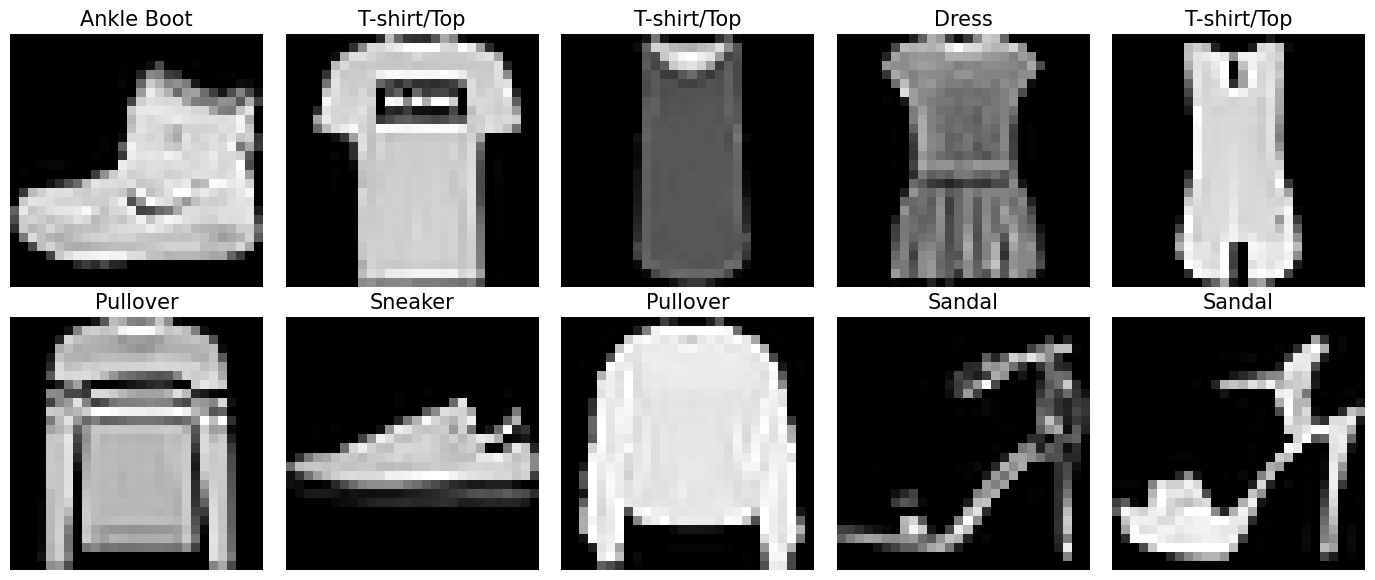

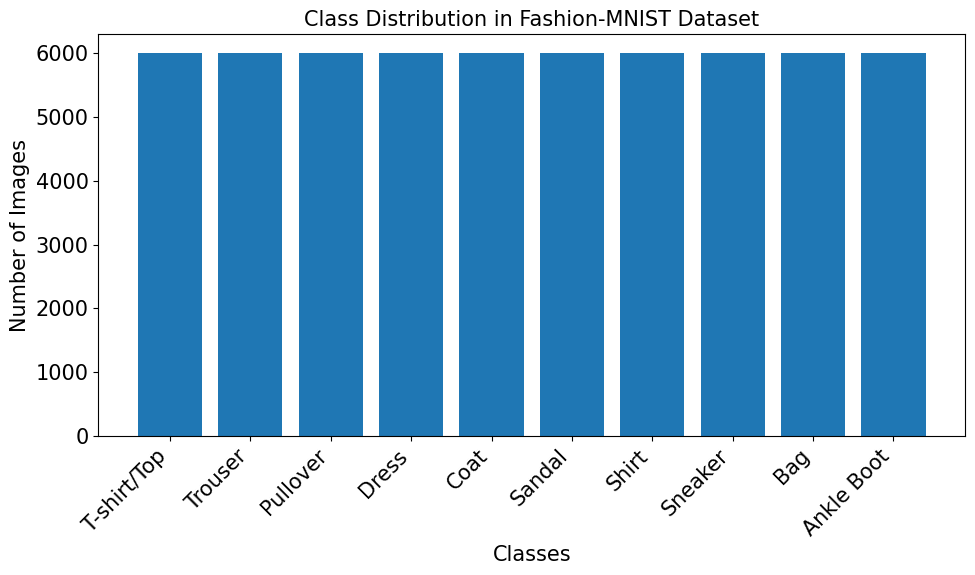

In [2]:
# -----------------------------
# Task 1 : Dataset Exploration
# -----------------------------

# Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Display dataset information
print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", x_test.shape)
print("Testing Labels Shape  :", y_test.shape)

# Class names
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

# Display 10 sample images
plt.figure(figsize=(14,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=15)
    plt.axis("off")

plt.tight_layout()

# Save figure
plt.savefig(
    "Sample_Images.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Plot class distribution
plt.figure(figsize=(10,6))

counts = np.bincount(y_train)

plt.bar(class_names, counts)

plt.xticks(rotation=45, ha="right", fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("Classes", fontsize=15)
plt.ylabel("Number of Images", fontsize=15)
plt.title("Class Distribution in Fashion-MNIST Dataset", fontsize=15)

plt.tight_layout()

plt.savefig(
    "Class_Distribution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


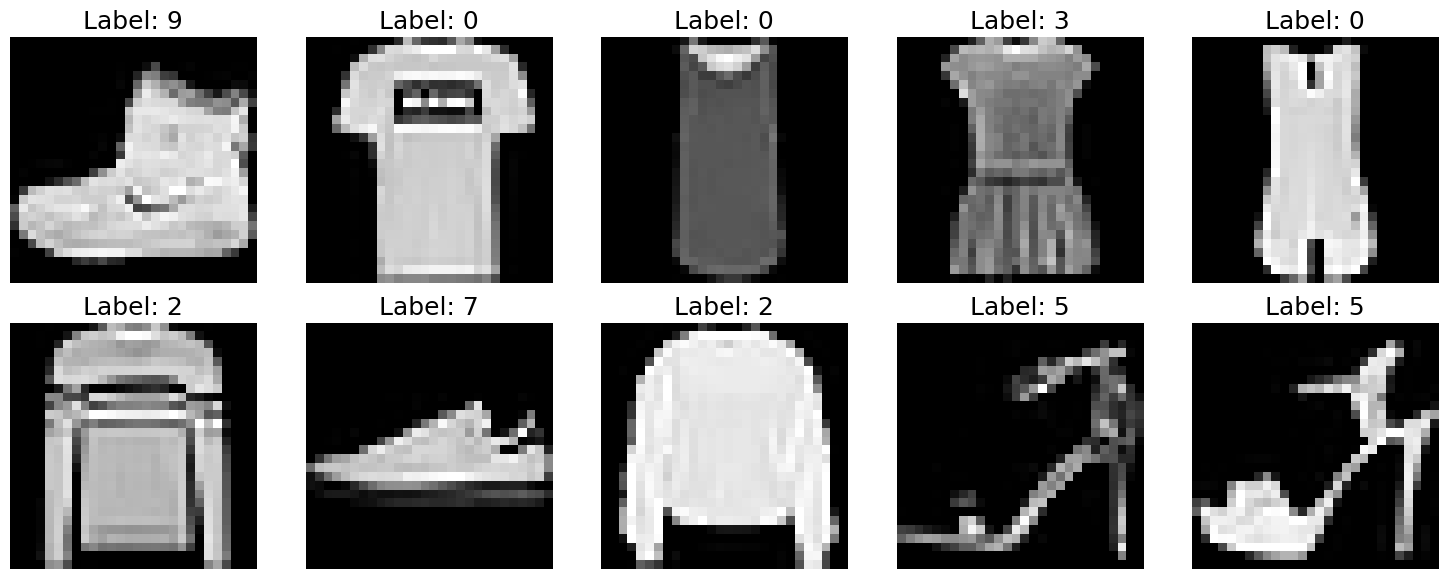

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')   # Remove cmap='gray' if using CIFAR-10
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.savefig("10_sample_images.png", dpi=600, bbox_inches='tight')
plt.show()

In [4]:
# ------------------------------------
# Task 3 : Model Construction
# ------------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create the MLP model
model = Sequential()

# First Hidden Layer
model.add(Dense(128,
                activation='relu',
                input_shape=(784,)))

# Second Hidden Layer
model.add(Dense(64,
                activation='relu'))

# Output Layer
model.add(Dense(10,
                activation='softmax'))

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras.utils import to_categorical

# Flatten images
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [8]:
# ------------------------------------
# Task 4 : Model Training
# ------------------------------------

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train,
    y_train_cat,
    validation_split=0.20,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8193 - loss: 0.5101 - val_accuracy: 0.8464 - val_loss: 0.4262
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8641 - loss: 0.3772 - val_accuracy: 0.8593 - val_loss: 0.3877
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8752 - loss: 0.3413 - val_accuracy: 0.8704 - val_loss: 0.3637
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8838 - loss: 0.3168 - val_accuracy: 0.8744 - val_loss: 0.3420
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8884 - loss: 0.2995 - val_accuracy: 0.8653 - val_loss: 0.3645
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8951 - loss: 0.2833 - val_accuracy: 0.8788 - val_loss: 0.3336
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8989 - loss: 0.2702 - val_accuracy: 0.8854 - val_loss: 0.3179
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9040 - loss: 0.2570 - 

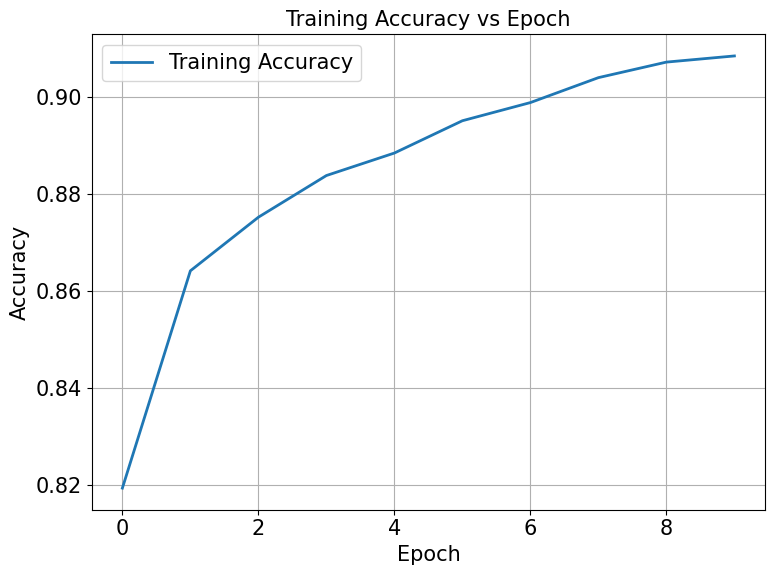

In [9]:
# ------------------------------------
# Training Accuracy vs Epoch
# ------------------------------------

plt.figure(figsize=(8,6))

plt.plot(history.history['accuracy'],
         linewidth=2,
         label='Training Accuracy')

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Accuracy", fontsize=15)
plt.title("Training Accuracy vs Epoch", fontsize=15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.grid(True)
plt.legend(fontsize=15)

plt.tight_layout()

plt.savefig(
    "Training_Accuracy.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

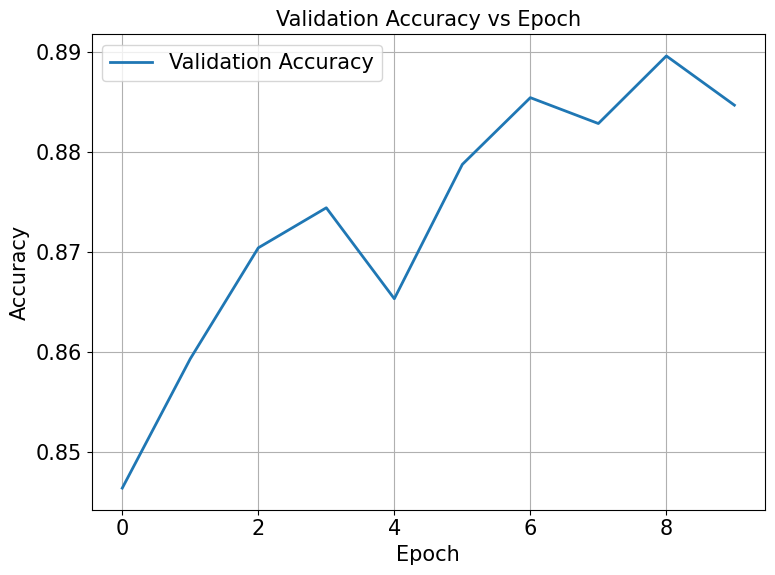

In [10]:
# ------------------------------------
# Validation Accuracy vs Epoch
# ------------------------------------

plt.figure(figsize=(8,6))

plt.plot(history.history['val_accuracy'],
         linewidth=2,
         label='Validation Accuracy')

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Accuracy", fontsize=15)
plt.title("Validation Accuracy vs Epoch", fontsize=15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.grid(True)
plt.legend(fontsize=15)

plt.tight_layout()

plt.savefig(
    "Validation_Accuracy.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

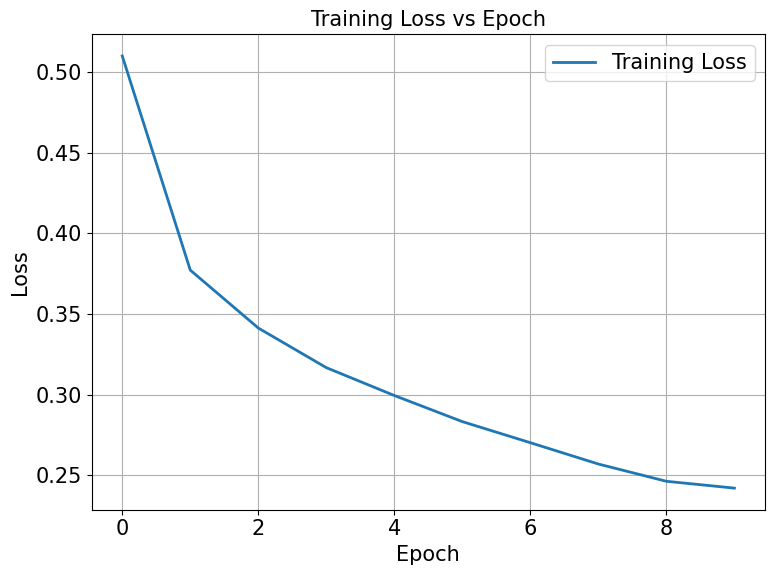

In [11]:
# ------------------------------------
# Training Loss vs Epoch
# ------------------------------------

plt.figure(figsize=(8,6))

plt.plot(history.history['loss'],
         linewidth=2,
         label='Training Loss')

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.title("Training Loss vs Epoch", fontsize=15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.grid(True)
plt.legend(fontsize=15)

plt.tight_layout()

plt.savefig(
    "Training_Loss.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

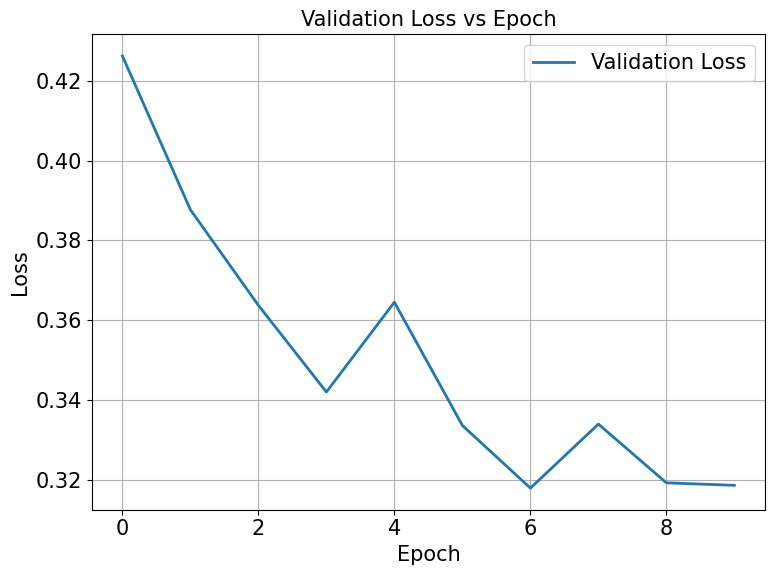

In [12]:
# ------------------------------------
# Validation Loss vs Epoch
# ------------------------------------

plt.figure(figsize=(8,6))

plt.plot(history.history['val_loss'],
         linewidth=2,
         label='Validation Loss')

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.title("Validation Loss vs Epoch", fontsize=15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.grid(True)
plt.legend(fontsize=15)

plt.tight_layout()

plt.savefig(
    "Validation_Loss.eps",
    dpi=600,
    format="eps",
    bbox_inches="tight"
)

plt.show()

In [13]:
# ------------------------------------
# Task 5 : Model Evaluation
# ------------------------------------

# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

# Predict class probabilities
y_pred_prob = model.predict(x_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded labels back to integers
y_true = np.argmax(y_test_cat, axis=1)

# Calculate performance metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# Print Classification Report
print("\nClassification Report\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Test Accuracy : 0.8751
Test Loss     : 0.3530
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Precision : 0.8761
Recall    : 0.8751
F1-Score  : 0.8742

Classification Report

              precision    recall  f1-score   support

 T-shirt/Top       0.83      0.83      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.83      0.71      0.77      1000
       Dress       0.84      0.92      0.88      1000
        Coat       0.74      0.87      0.80      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.72      0.65      0.68      1000
     Sneaker       0.92      0.95      0.93      1000
         Bag       0.98      0.97      0.97      1000
  Ankle Boot       0.94      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



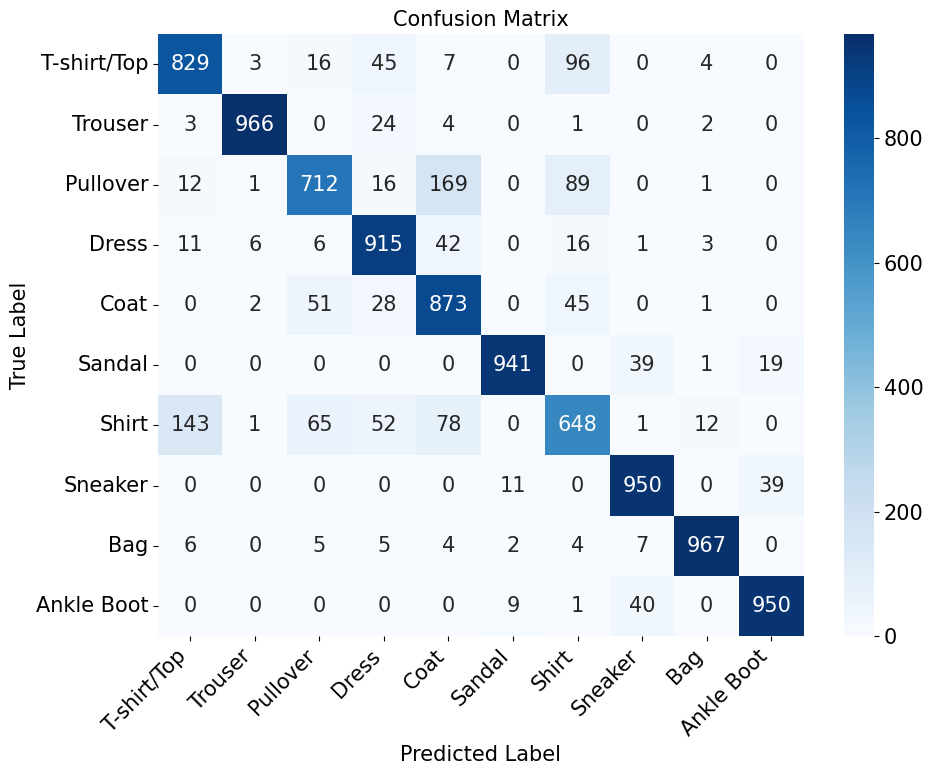

In [14]:
# ------------------------------------
# Confusion Matrix
# ------------------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label", fontsize=15)
plt.ylabel("True Label", fontsize=15)
plt.title("Confusion Matrix", fontsize=15)

plt.xticks(rotation=45, ha="right", fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()

plt.savefig(
    "Confusion_Matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [15]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.8 MB/s eta 0:00:00


In [16]:
import keras_tuner as kt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

In [ ]:
def build_model(hp):

    model = Sequential()

    # Number of hidden layers
    num_layers = hp.Int(
        "hidden_layers",
        min_value=1,
        max_value=3,
        step=1
    )

    # Number of neurons
    units = hp.Choice(
        "neurons",
        values=[32,64,128,256]
    )

    # Activation
    activation = hp.Choice(
        "activation",
        values=["relu","tanh","sigmoid"]
    )

    # Dropout
    dropout = hp.Choice(
        "dropout",
        values=[0.0,0.2,0.5]
    )

    # First layer
    model.add(Dense(units,
                    activation=activation,
                    input_shape=(784,)))

    if dropout > 0:
        model.add(Dropout(dropout))

    # Remaining hidden layers
    for i in range(num_layers-1):

        model.add(Dense(units,
                        activation=activation))

        if dropout > 0:
            model.add(Dropout(dropout))

    model.add(Dense(10,activation="softmax"))

    # Learning Rate
    lr = hp.Choice(
        "learning_rate",
        values=[0.1,0.01,0.001]
    )

    # Optimizer
    optimizer_name = hp.Choice(
        "optimizer",
        values=["adam","sgd","rmsprop"]
    )

    if optimizer_name=="adam":
        optimizer=Adam(learning_rate=lr)

    elif optimizer_name=="sgd":
        optimizer=SGD(learning_rate=lr)

    else:
        optimizer=RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(

    build_model,

    objective="val_accuracy",

    max_trials=10,

    overwrite=True,

    directory="Hyperparameter_Search",

    project_name="FashionMNIST_MLP"

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
tuner.search(

    x_train,

    y_train_cat,

    validation_split=0.2,

    epochs=20,

    batch_size=32,

    verbose=1

)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    max_iter=50,
    random_state=42
)

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'learning_rate_init': [0.001],
    'batch_size': [32],
    'max_iter': [50]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from datetime import datetime
import time

print("="*60)
print("Hyperparameter Search Started")
print("Start Time:", datetime.now())
print("="*60)

random_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_grid,
    n_iter=2,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=1,      # Keep as 1 so progress is printed in order
    verbose=10     # Maximum verbosity
)

start = time.time()

random_search.fit(x_train, y_train_cat)

end = time.time()

print("\n" + "="*60)
print("Hyperparameter Search Finished")
print("End Time:", datetime.now())
print(f"Total Time: {end-start:.2f} seconds")
print("="*60)

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

In [ ]:
print(x_train.shape)

In [17]:
import numpy as np
import matplotlib.pyplot as plt

class PerceptronGate:
    def __init__(self, learning_rate=0.1, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y, gate_name):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.weight_history = [(self.weights.copy(), self.bias)]
        self.errors_per_epoch = []
        update_count = 0

        print(f"\n{'='*60}")
        print(f"Training Perceptron for {gate_name} Gate")
        print(f"{'='*60}")
        print(f"Initial Weights: {self.weights}, Initial Bias: {self.bias}\n")

        for epoch in range(self.epochs):
            total_errors = 0
            for i in range(n_samples):
                z = np.dot(X[i], self.weights) + self.bias
                y_pred = 1 if z >= 0 else 0
                error = y[i] - y_pred

                if error != 0:
                    update_count += 1
                    self.weights = self.weights + self.lr * error * X[i]
                    self.bias = self.bias + self.lr * error
                    self.weight_history.append((self.weights.copy(), self.bias))
                    total_errors += 1

                    print(f"Update {update_count:2d} | Epoch {epoch+1:2d} | "
                          f"Input {X[i]} | Target {y[i]} | Predicted {y_pred} | "
                          f"Weights = {self.weights} | Bias = {self.bias:.2f}")

            self.errors_per_epoch.append(total_errors)
            if total_errors == 0:
                print(f"\nConverged after epoch {epoch+1} with zero misclassifications.\n")
                return self

        print(f"\nDid NOT converge after {self.epochs} epochs "
              f"(misclassifications per epoch: {self.errors_per_epoch})\n")
        print(f"Weights never stabilize -- final Weights: {self.weights}, final Bias: {self.bias}")
        return self

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return np.where(z >= 0, 1, 0)

In [18]:
def detect_cycle(weight_history, max_period=12):
    states = [tuple(np.round(w, 4).tolist() + [round(b, 4)]) for w, b in weight_history]
    n = len(states)
    for period in range(1, max_period + 1):
        if n - 1 - 2 * period < 0:
            break
        tail = states[-period:]
        prev = states[-2 * period:-period]
        if tail == prev:
            return period, states[-period:]
    return None, None

In [19]:
def plot_decision_boundaries_2d(X, y, weight_history, gate_name, n_show=None):
    states = weight_history if n_show is None else weight_history[:n_show]
    n_states = len(states)
    cols = 4
    rows = int(np.ceil(n_states / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 3.8 * rows))
    axes = np.array(axes).reshape(-1)

    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    for idx, (w, b) in enumerate(states):
        ax = axes[idx]

        for label, marker, color in [(0, 'o', 'red'), (1, 's', 'blue')]:
            pts = X[y == label]
            ax.scatter(pts[:, 0], pts[:, 1], marker=marker, color=color,
                       s=110, edgecolor='black', linewidth=1.2, label=f'Class {label}', zorder=3)

        xx = np.linspace(x_min, x_max, 100)
        if w[1] != 0:
            yy = -(w[0] * xx + b) / w[1]
            ax.plot(xx, yy, 'k-', linewidth=2)
        elif w[0] != 0:
            ax.axvline(x=-b / w[0], color='k', linewidth=2)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title("Initial" if idx == 0 else f"Update {idx}", fontsize=10)
        ax.set_xlabel("Input 1", fontsize=9)
        ax.set_ylabel("Input 2", fontsize=9)
        ax.legend(fontsize=7, loc='lower left')
        ax.grid(True, alpha=0.4)

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    suffix = f" (first {n_states} states)" if n_show else ""
    plt.suptitle(f"Decision Boundary Evolution -- {gate_name} Gate{suffix}", fontsize=15)
    plt.tight_layout()
    plt.savefig(f"{gate_name}_Decision_Boundary.eps", dpi=600, format="eps", bbox_inches="tight")
    plt.savefig(f"{gate_name}_Decision_Boundary.png", dpi=150, bbox_inches="tight")
    plt.show()

In [20]:
def plot_errors_per_epoch(errors_per_epoch, gate_name):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(errors_per_epoch) + 1), errors_per_epoch, marker='o', linewidth=2)
    plt.title(f"Misclassifications per Epoch -- {gate_name} Gate", fontsize=15)
    plt.xlabel("Epoch", fontsize=13)
    plt.ylabel("Number of Misclassified Samples", fontsize=13)
    plt.xticks(range(1, len(errors_per_epoch) + 1))
    plt.grid(True, alpha=0.5)
    plt.savefig(f"{gate_name}_Errors_Per_Epoch.eps", dpi=600, format="eps", bbox_inches="tight")
    plt.savefig(f"{gate_name}_Errors_Per_Epoch.png", dpi=150, bbox_inches="tight")
    plt.show()

In [21]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

xor_model = PerceptronGate(learning_rate=0.1, epochs=10)
xor_model.fit(X_xor, y_xor, "XOR")


Training Perceptron for XOR Gate
Initial Weights: [0. 0.], Initial Bias: 0.0

Update  1 | Epoch  1 | Input [0 0] | Target 0 | Predicted 1 | Weights = [0. 0.] | Bias = -0.10
Update  2 | Epoch  1 | Input [0 1] | Target 1 | Predicted 0 | Weights = [0.  0.1] | Bias = 0.00
Update  3 | Epoch  1 | Input [1 1] | Target 0 | Predicted 1 | Weights = [-0.1  0. ] | Bias = -0.10
Update  4 | Epoch  2 | Input [0 1] | Target 1 | Predicted 0 | Weights = [-0.1  0.1] | Bias = 0.00
Update  5 | Epoch  2 | Input [1 0] | Target 1 | Predicted 0 | Weights = [0.  0.1] | Bias = 0.10
Update  6 | Epoch  2 | Input [1 1] | Target 0 | Predicted 1 | Weights = [-0.1  0. ] | Bias = 0.00
Update  7 | Epoch  3 | Input [0 0] | Target 0 | Predicted 1 | Weights = [-0.1  0. ] | Bias = -0.10
Update  8 | Epoch  3 | Input [0 1] | Target 1 | Predicted 0 | Weights = [-0.1  0.1] | Bias = 0.00
Update  9 | Epoch  3 | Input [1 0] | Target 1 | Predicted 0 | Weights = [0.  0.1] | Bias = 0.10
Update 10 | Epoch  3 | Input [1 1] | Target 0 

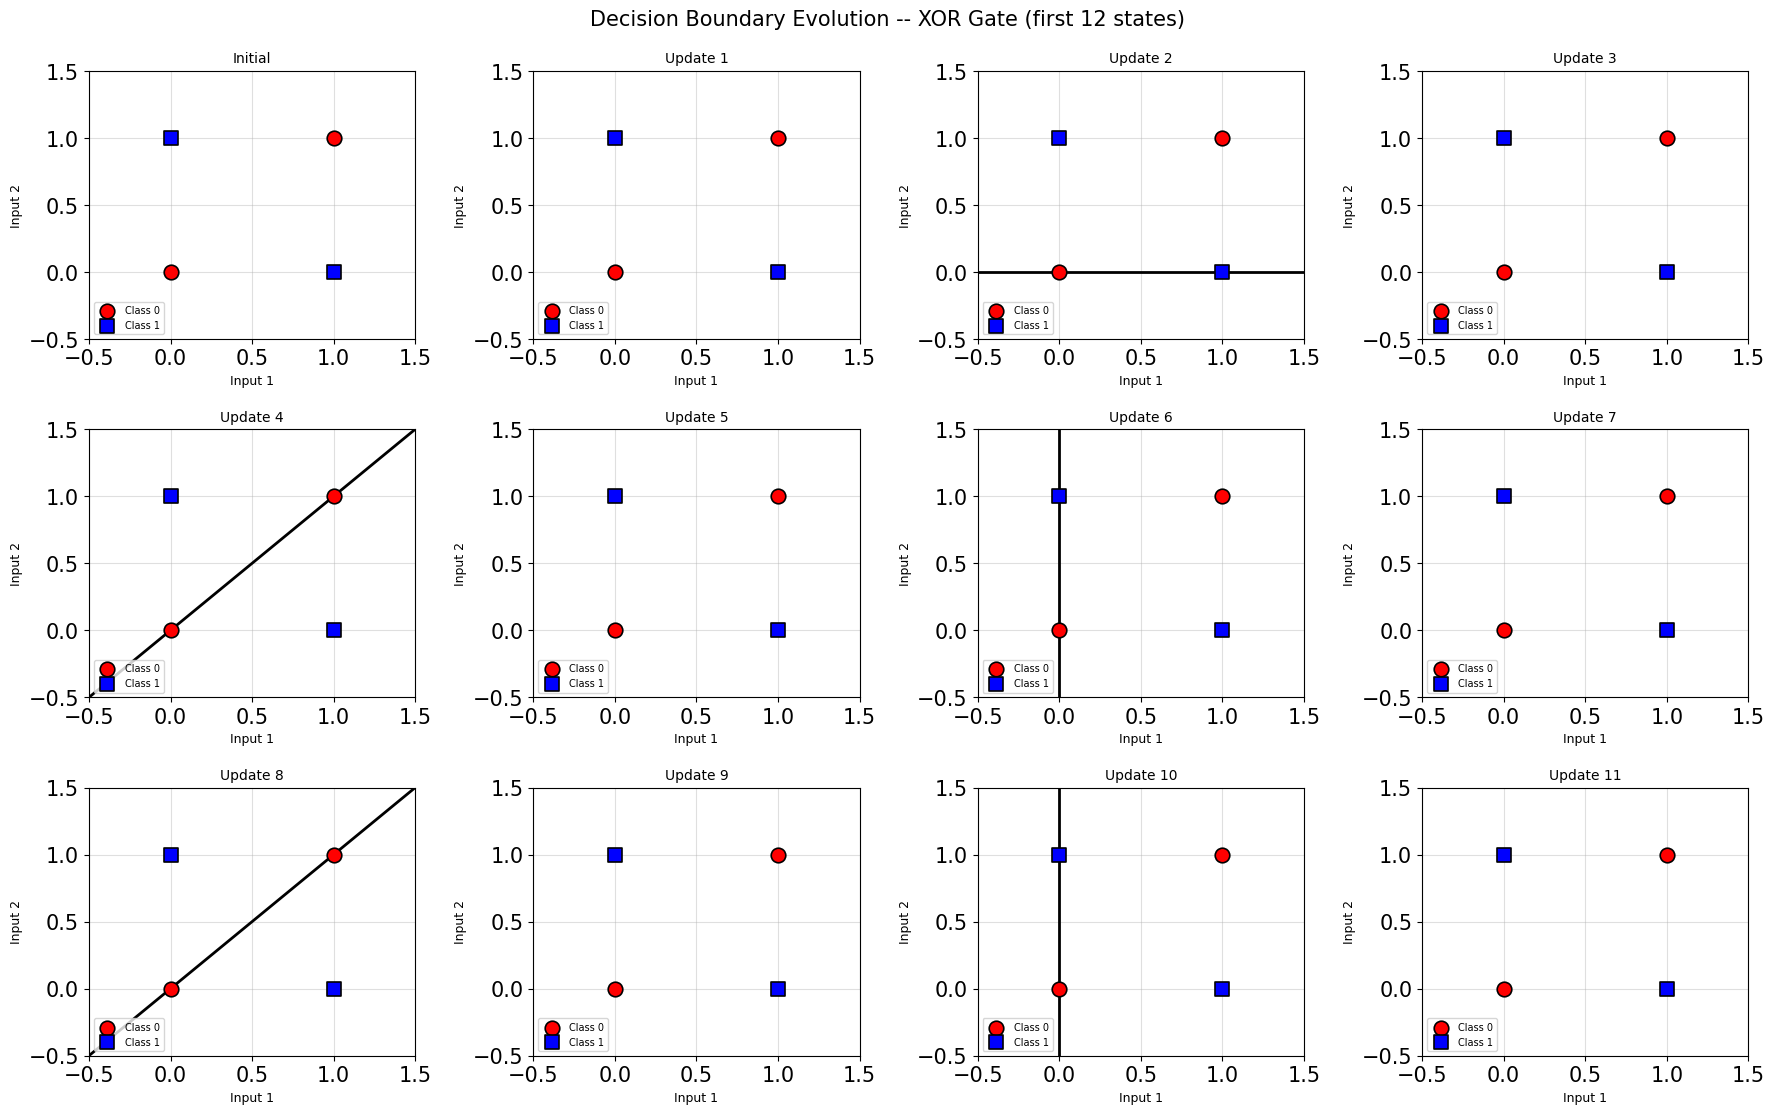

In [22]:
plot_decision_boundaries_2d(X_xor, y_xor, xor_model.weight_history, "XOR", n_show=12)

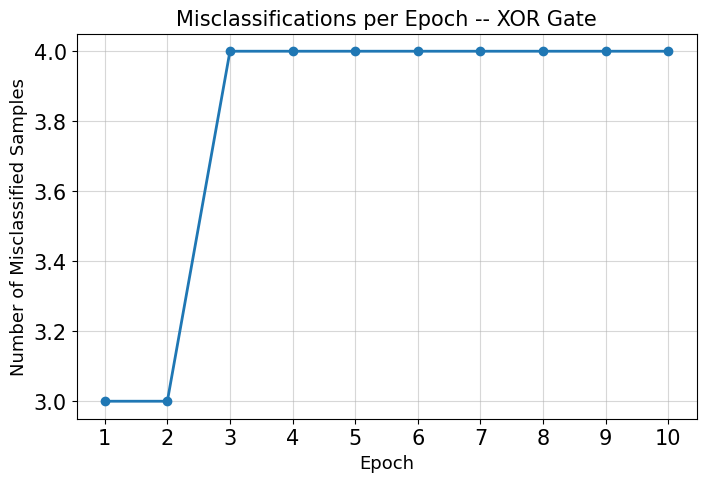

In [23]:
plot_errors_per_epoch(xor_model.errors_per_epoch, "XOR")

In [24]:
period, cycle_states = detect_cycle(xor_model.weight_history)

print(f"\n{'='*60}")
print("Non-Convergence Pattern Analysis")
print(f"{'='*60}")
if period:
    print(f"The weight vector enters a repeating cycle of period {period} "
          f"updates and never stabilizes:")
    for s in cycle_states:
        print("  weights =", s[:-1], ", bias =", s[-1])
else:
    print("No short repeating cycle detected in the inspected window.")

print("\nFinal prediction on XOR inputs:", xor_model.predict(X_xor), " (target:", y_xor, ")")


Non-Convergence Pattern Analysis
The weight vector enters a repeating cycle of period 4 updates and never stabilizes:
  weights = (-0.1, 0.0) , bias = -0.1
  weights = (-0.1, 0.1) , bias = 0.0
  weights = (0.0, 0.1) , bias = 0.1
  weights = (-0.1, 0.0) , bias = 0.0

Final prediction on XOR inputs: [1 1 0 0]  (target: [0 1 1 0] )
